# 5 · Bayesian model comparison

The full workflow: fit **AT2017GFO** (the GW170817 kilonova) with kilonova models of increasing complexity — **one, two, and three ejecta components** — using **ABC**, **SNPE**, and **MCMC**, then compare them with information criteria to ask *how many components the data support*.

Requires the optional **redback** backend. Budgets here are deliberately small so the notebook runs in minutes; scale `n_simulations` / `nsteps` up for publication-grade posteriors.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import whisper_labia as wp
from redback.model_library import all_models_dict
from whisper_labia.models.two_component_kilonova import _redback_band

wp.__version__

/opt/conda/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


15:31 bilby INFO    : Running bilby version: 2.8.0


15:31 redback INFO    : Running redback version: 1.12.0


'0.0.1.dev0'

## Data — preprocessed AT2017GFO

The preprocessed UVOIR reduction (Swift-UVOT `uvw1` dropped, SNR > 5, one point per band per epoch). We keep four well-sampled bands and the first 15 days for speed.

In [2]:
csv = next(p for p in [
    Path('../analysis/at2017gfo_villar/data/at2017gfo_full_preprocessed.csv'),
    Path('analysis/at2017gfo_villar/data/at2017gfo_full_preprocessed.csv')] if p.exists())
Z = 0.0098
lc = wp.load_lightcurve(csv, redshift=Z, explosion_date=57982.529, bands=['g', 'r', 'i'])
lc = lc[np.asarray(lc.time) <= 12.0]
print(lc.n_points, 'points |', lc.bands)

133 points | ['g', 'i', 'r']


## Models — a one/two/three-component ladder

redback exposes one-, two-, and three-component kilonova models. We wrap each as a WHISPER `predict(params, times, bands) -> flux [Jy]`, fitting **mej, vej, kappa per component** and fixing the redshift and (for 2/3-comp) the temperature floors. This gives a clean **3 / 6 / 9** parameter ladder.

In [3]:
AB = 3631.0

class KilonovaModel:
    """Picklable predict(params, times, bands) -> flux [Jy] wrapping a redback kilonova model.

    A class (not a closure) so it pickles for parallel ABC/MCMC (`n_jobs > 1`). It stores only
    the redback model name + parameter lists; the model function is looked up per call."""
    def __init__(self, redback_name, param_names, fixed):
        self.redback_name, self.param_names, self.fixed = redback_name, param_names, fixed
    def __call__(self, p, times, bands):
        fn = all_models_dict[self.redback_name]
        t = np.clip(np.asarray(times, float), 0.1, None)
        bands = np.asarray(bands)
        kw = {k: float(p[k]) for k in self.param_names}
        kw.update(self.fixed); kw['redshift'] = Z
        out = np.empty(t.shape)
        for b in np.unique(bands):
            sel = bands == b
            mag = np.asarray(fn(t[sel], output_format='magnitude',
                                bands=[_redback_band(b)], **kw), float)
            mag = np.nan_to_num(mag, nan=40.0, posinf=40.0, neginf=40.0)
            out[sel] = AB * 10 ** (-0.4 * mag)
        return out

In [4]:
# priors: mej [Msun] log-uniform, vej [c] uniform, kappa [cm^2/g] uniform, per component
def comp(i):
    return {f'mej_{i}': wp.LogUniform(1e-3, 0.1), f'vej_{i}': wp.Uniform(0.05, 0.3),
            f'kappa_{i}': wp.Uniform(0.5, 30.0)}

FLOOR = 2500.0                              # temperature floor fixed (2/3-comp models)
LADDER = {  # name: (redback model, free params, fixed non-redshift params)
    'kn1': ('one_component_kilonova_model',   ['mej', 'vej', 'kappa'], {}),
    'kn2': ('two_component_kilonova_model',
            ['mej_1', 'vej_1', 'kappa_1', 'mej_2', 'vej_2', 'kappa_2'],
            dict(temperature_floor_1=FLOOR, temperature_floor_2=FLOOR)),
    'kn3': ('three_component_kilonova_model',
            ['mej_1', 'vej_1', 'kappa_1', 'mej_2', 'vej_2', 'kappa_2',
             'mej_3', 'vej_3', 'kappa_3'],
            dict(temperature_floor_1=FLOOR, temperature_floor_2=FLOOR, temperature_floor_3=FLOOR)),
}
PRIORS = {
    'kn1': wp.Prior({'mej': wp.LogUniform(1e-3, 0.1), 'vej': wp.Uniform(0.05, 0.3),
                     'kappa': wp.Uniform(0.5, 30.0)}),
    'kn2': wp.Prior({**comp(1), **comp(2)}),
    'kn3': wp.Prior({**comp(1), **comp(2), **comp(3)}),
}
for name, (rb, params, fixed) in LADDER.items():
    wp.register_model(name, KilonovaModel(rb, params, fixed), params, overwrite=True)
print('registered:', list(LADDER))

registered: ['kn1', 'kn2', 'kn3']


## Fit — 3 models × 3 samplers

Same interface for every fit. ABC and SNPE are likelihood-free; MCMC uses the exact Gaussian likelihood. redback is CPU-only and semi-analytic, so we keep small budgets (`n_jobs` / `num_workers` parallelise the simulations) and fit **one model per cell** — each takes a couple of minutes.

In [5]:
def fit_all(name):
    prior = PRIORS[name]
    abc  = wp.fit_ABC(lc, name, prior=prior, n_simulations=3000, quantile=0.03,
                      n_jobs=8, seed=0)
    snpe = wp.fit_SNPE(lc, name, prior=prior, num_rounds=1, num_simulations=1500,
                       num_samples=1500, num_workers=8, seed=0)
    mcmc = wp.fit_MCMC(lc, name, prior=prior, nsteps=800, burnin=300, n_jobs=8, seed=0)
    return {'ABC': abc, 'SNPE': snpe, 'MCMC': mcmc}

results = {}

In [6]:
results['kn1'] = fit_all('kn1'); print('kn1 (3 params) done')

2026-07-07 15:32:31.606232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 15:32:31.633862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783438351.672621   26131 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783438351.682145   26131 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783438351.705889   26131 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


15:32 bilby INFO    : Running bilby version: 2.8.0
15:32 redback INFO    : Running redback version: 1.12.0


15:32 bilby INFO    : Running bilby version: 2.8.0
15:32 redback INFO    : Running redback version: 1.12.0
2026-07-07 15:32:42.866568: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 15:32:42.914343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783438362.970681   26401 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783438362.995076   26401 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
15:32 bilby INFO    : Running bilby 

...

2026-07-07 15:32:44.789923: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 15:32:44.819415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-07 15:32:44.832995: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1783438364.854469   26514 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783438364.8639

W0000 00:00:1783438364.999489   26526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783438365.002252   26526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783438365.002263   26526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783438365.002266   26526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
2026-07-07 15:32:45.011894: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with 

2026-07-07 15:32:45.395095: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 15:32:45.435883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783438365.488417   26491 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783438365.500885   26491 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783438365.537315   26491 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

 Neural network successfully converged after 169 epochs.

kn1 (3 params) done


In [7]:
results['kn2'] = fit_all('kn2'); print('kn2 (6 params) done')

15:53 bilby INFO    : Running bilby version: 2.8.0
15:53 redback INFO    : Running redback version: 1.12.0


15:53 bilby INFO    : Running bilby version: 2.8.0
15:53 redback INFO    : Running redback version: 1.12.0
15:53 bilby INFO    : Running bilby version: 2.8.0
15:53 redback INFO    : Running redback version: 1.12.0


15:53 bilby INFO    : Running bilby version: 2.8.0
15:53 redback INFO    : Running redback version: 1.12.0


15:53 bilby INFO    : Running bilby version: 2.8.0
15:53 redback INFO    : Running redback version: 1.12.0
2026-07-07 15:53:34.694421: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2026-07-07 15:53:34.728796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783439614.766292   27355 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783439614.777504   27355 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783439614.811941   27355 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783439614.811984   27355 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783439614.811988   27355 computation_placer.cc:177] computation placer alr

...

E0000 00:00:1783439615.492390   27392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783439615.503338   27392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783439615.530326   27392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783439615.530468   27392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783439615.530509   27392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783439615.530529   27392 computation_placer.cc:177] computation placer already registered. Please check linka

2026-07-07 15:53:35.766513: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 15:53:35.796479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783439615.835070   27393 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-07 15:53:35.840621: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1783439615.8477

2026-07-07 15:53:36.020073: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 15:53:36.054500: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783439616.094982   27417 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783439616.107400   27417 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783439616.137567   27417 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

 Neural network successfully converged after 232 epochs.

kn2 (6 params) done


In [8]:
results['kn3'] = fit_all('kn3'); print('kn3 (9 params) done')

16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0
16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0
16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0
16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0
16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0


16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0
16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0


16:08 bilby INFO    : Running bilby version: 2.8.0
16:08 redback INFO    : Running redback version: 1.12.0


2026-07-07 16:08:50.090948: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 16:08:50.125638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-07 16:08:50.126207: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 16:08:50.162587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been reg

2026-07-07 16:08:50.293581: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1783440530.295771   28269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783440530.295958   28269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783440530.295990   28269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783440530.296010   28269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
2026-0

2026-07-07 16:08:50.657162: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 16:08:50.693648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783440530.735951   28305 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783440530.748714   28305 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783440530.781901   28305 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

 Neural network successfully converged after 158 epochs.

kn3 (9 params) done


## Compare

**AIC** and **BIC** (from the exact Gaussian log-likelihood at the best draw, both penalising parameter count) let us compare the complexity ladder on equal footing. Lower is better; BIC penalises extra parameters more strongly.

In [9]:
rows = []
for name in LADDER:
    k = len(LADDER[name][1])
    for sampler, r in results[name].items():
        rows.append(dict(model=name, k=k, sampler=sampler,
                         AIC=round(r.aic, 1), BIC=round(r.bic, 1),
                         runtime_s=round(r.runtime_s, 1)))
tbl = pd.DataFrame(rows)
tbl.pivot_table(index=['model', 'k'], columns='sampler', values='AIC')

,sampler,ABC,MCMC,SNPE
model,k,,,
kn1,3,55803.2,26193.3,27882.1
kn2,6,80036.7,21489.5,27767.0
kn3,9,58860.4,33350.5,27104.8


Read the table down each column: if AIC/BIC keeps dropping from `kn1`→`kn2`→`kn3`, the data reward the extra component; if it flattens or rises, the simpler model is preferred (added components are unconstrained). The three samplers should agree on the trend.

In [10]:
# best (lowest-AIC) fit overall
best = min(rows, key=lambda d: d['AIC'])
print('best by AIC:', best['model'], 'via', best['sampler'], '(AIC', best['AIC'], ')')
br = results[best['model']][best['sampler']]
br.summary

best by AIC: kn2 via MCMC (AIC 21489.5 )


{'mej_1': {'median': 0.0773289728731253,
  'ci16': 0.06333413806341487,
  'ci84': 0.09036357092287171,
  'mean': 0.07652955309350236,
  'std': 0.01267336726884573},
 'vej_1': {'median': 0.296475854241826,
  'ci16': 0.23772539356762554,
  'ci84': 0.29951246476900556,
  'mean': 0.2574739548597147,
  'std': 0.059183573443531076},
 'kappa_1': {'median': 0.7047025308036114,
  'ci16': 0.5035394590054447,
  'ci84': 1.215086001694479,
  'mean': 0.7997931858991209,
  'std': 0.3396119604512028},
 'mej_2': {'median': 0.08404495989568528,
  'ci16': 0.011981558682450778,
  'ci84': 0.0889766973413802,
  'mean': 0.05751491998163761,
  'std': 0.03451783641066571},
 'vej_2': {'median': 0.26222248011591365,
  'ci16': 0.2377312956341055,
  'ci84': 0.29856373513737283,
  'mean': 0.2683930296928413,
  'std': 0.027465942360707884},
 'kappa_2': {'median': 1.0023718170489289,
  'ci16': 0.6595440401080371,
  'ci84': 22.203313918566888,
  'mean': 7.9621310893567445,
  'std': 10.089444915827952}}

## Posterior of the preferred model

Overlay the three samplers' posteriors for the preferred model — agreement is the sign of a well-constrained fit.

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


...

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


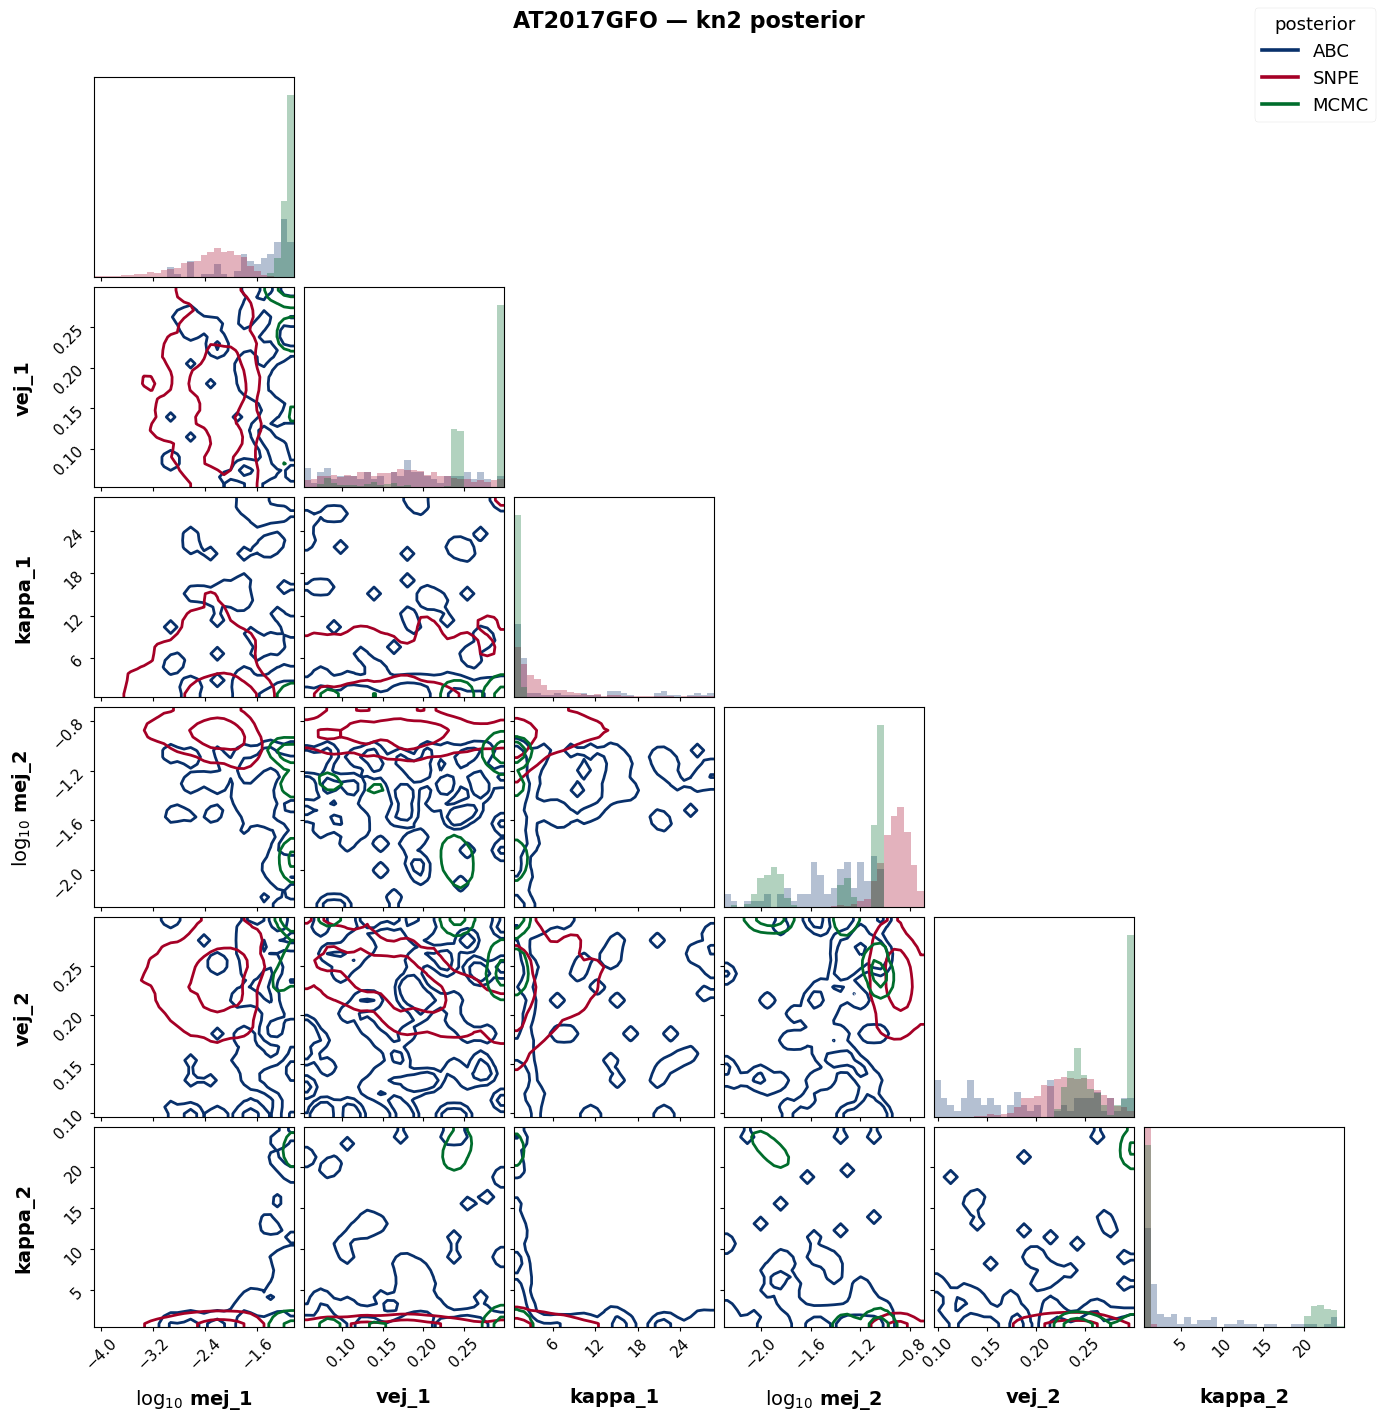

In [11]:
name = best['model']
wp.plot_corner([results[name][s].samples for s in ['ABC', 'SNPE', 'MCMC']],
               labels=['ABC', 'SNPE', 'MCMC'], parameters=LADDER[name][1],
               log_params=[p for p in LADDER[name][1] if p.startswith('mej')],
               title=f'AT2017GFO — {name} posterior');

## Summary

One interface (`fit_<sampler>`), one registry (`register_model`) — swapping model complexity and inference method is a one-line change, and AIC/BIC give a consistent, cross-sampler model ranking. Scale the budgets up (and add the temperature floors / a Villar+17 scatter term) for a production analysis; see [`analysis/at2017gfo_villar/`](../analysis/at2017gfo_villar/) for the full study.